<a href="https://colab.research.google.com/github/farankhandev/flyrank-ml-internship/blob/main/notebooks/03_working_with_the_full_release.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weeks 3+ — Working with the full release (~79M rows) without downloading 79M rows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farankhandev/flyrank-ml-internship/blob/main/notebooks/03_working_with_the_full_release.ipynb)

Notebooks 01–02 used the small starter CSV that ships with this repo. Your lane and capstone work
run on the **full pseudonymized warehouse release**: ~17 months of daily search performance for
~70 clients, plus a query-level table. It is hosted as Parquet on Hugging Face, and the trick of
this notebook is that you **never download or load the whole thing** — DuckDB reads only the
columns and partitions your SQL touches.

By the end you will have:
1. Connected DuckDB to the hosted release and listed every table.
2. Pulled a **feature table you designed** (aggregates per content item) into pandas.
3. Trained a quick scikit-learn model on features you built from 79M rows — on a free Colab CPU.

**Before you start (one-time, ~2 minutes):**
1. Create a free [Hugging Face account](https://huggingface.co/join).
2. Open the dataset page ([`FlyRank/internship-warehouse`](https://huggingface.co/datasets/FlyRank/internship-warehouse)) and **request access** (instant after you accept the data-use terms). **Accept the terms in your browser first — the token below 401s until access is granted (usually instant).**
3. Create a **read** token at [Settings → Access Tokens](https://huggingface.co/settings/tokens). **Never paste the token into a code cell** — your repo is public; use the `getpass` prompt below (or Colab's 🔑 Secrets panel).


In [ ]:
%pip -q install duckdb huggingface_hub


In [ ]:
import os, getpass


HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


Paste your Hugging Face READ token (hf_...): ··········


## 1. Connect DuckDB to the release

DuckDB speaks `hf://` natively. The secret below authenticates every query; after that the
release behaves like a set of local tables.


In [ ]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


That count over the daily fact touched **Parquet metadata, not data** — it finished in seconds
even though the table has ~79M rows. That is the whole workflow: push the heavy lifting into
DuckDB SQL, bring only small results into pandas.

## 2. Know your panel before you model it

History depth **differs per client** (an *unbalanced panel*). `dim_clients` tells you exactly
what each client has — check it before designing any time window.


In [ ]:
clients = con.sql(f"""
    SELECT
        client_hash_id,
        gsc_data_start,
        ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

gsc_dates = clients['gsc_data_start'].dropna()

print(
    "Clients with at least 12 months of GSC history:",
    (
        clients['gsc_data_start']
        <= gsc_dates.max() - __import__('pandas').Timedelta(days=365)
    ).sum()
)

clients.head(10)


clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


## 3. Build features with SQL, not with RAM

The pattern for every lane: **aggregate per content item inside DuckDB**, then hand the small
result to pandas/sklearn. Here: momentum features from the last 60 days of the panel.

**This is the heaviest cell in the notebook — expect 2–6 minutes on Colab.** It downloads ~2 months of column data over the network (RAM stays tiny; that's the point). If it runs past ~10 minutes or errors with `HTTP 429`, re-run this section against `TABLES['fact_daily_sample']` and save the full table for your final pass.


### 2. Build the performance feature table

The daily performance data is aggregated into two consecutive 30-day periods based on the latest available report date.

The previous 30-day period provides historical performance signals, while the latest 30-day period is used later to define the observed decline label.

Content items with fewer than 100 impressions in the previous period are excluded to avoid making the decline comparison on very low-volume observations.


In [ ]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d
        FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT
            f.client_hash_id,
            f.content_hash_id,

            SUM(CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                THEN f.gsc_impressions ELSE 0
            END) AS imp_last30,

            SUM(CASE
                WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                THEN f.gsc_impressions ELSE 0
            END) AS imp_prev30,

            SUM(CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                THEN f.gsc_clicks ELSE 0
            END) AS clk_last30,

            AVG(CASE
                WHEN f.report_date > b.end_d - INTERVAL 30 DAY
                THEN f.gsc_avg_position
            END) AS pos_last30

        FROM {TABLES['fact_daily']} f, bounds b

        WHERE f.report_date > b.end_d - INTERVAL 60 DAY

        GROUP BY 1, 2

        HAVING imp_prev30 >= 100
    )

    SELECT *
    FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

111,247 content items with enough history


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483


### 3. Add query-level signals

Query-level information is aggregated for each content item from the available 90-day query table.

The resulting signals include visible query count, rare-query share, anonymized-query share, the largest query's impressions, and the share of impressions represented by that largest query.

These signals are joined to the performance feature table using the anonymized content identifier.


In [ ]:
qsignals = con.sql(f"""
    SELECT
        content_hash_id,
        ANY_VALUE(content_visible_query_count) AS visible_queries,
        ANY_VALUE(rare_impressions_share) AS rare_share,
        ANY_VALUE(anonymized_impressions_share) AS anon_share,
        MAX(impressions_90d) AS top_query_impressions,
        SUM(impressions_90d) AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = (
    qsignals['top_query_impressions'] /
    qsignals['kept_impressions']
)

data = features.merge(
    qsignals,
    on='content_hash_id',
    how='left'
)

print(f'Joined: {len(data):,} rows')
data.head()

Joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159,15.0,0.144623,0.665019,79.0,308.0,0.256494
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091,101.0,0.037423,0.178737,15557.0,18432.0,0.844021
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206,3.0,0.215054,0.623656,25.0,60.0,0.416667
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655,16.0,0.032740,0.717915,473.0,952.0,0.496849
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483,8.0,0.224066,0.630705,30.0,140.0,0.214286


### 4. Define the decline label and modeling features

A content item is labeled as declining when impressions in the latest 30-day period are below 80% of impressions in the previous 30-day period.

The model uses five features: previous 30-day impressions, visible query count, rare-query impression share, anonymized-query impression share, and top-query impression share.

Rows with missing values in any of these five features are excluded from the modeling dataset.



In [ ]:
data['is_declining'] = (
    data['imp_last30'] < 0.8 * data['imp_prev30']
).astype(int)

feature_cols = [
    'imp_prev30',
    'visible_queries',
    'rare_share',
    'anon_share',
    'top_query_share'
]

model_data = data.dropna(subset=feature_cols).copy()

print(f"Rows available for modeling: {len(model_data):,}")
print(f"Declining pages: {model_data['is_declining'].sum():,}")
print(f"Declining rate: {model_data['is_declining'].mean():.1%}")

Rows available for modeling: 102,203
Declining pages: 64,646
Declining rate: 63.3%


### 5. Train and validate the Random Forest

A Random Forest classifier with 200 trees is trained to identify content items labeled as declining.

The data is split at the client level using `GroupShuffleSplit`, so content from the same client does not appear in both the training and test sets. This provides a stronger test of generalization to unseen clients.

The model produces both predicted labels and probabilities. ROC-AUC is used to evaluate how well the model separates declining from non-declining content.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, roc_auc_score

X = model_data[feature_cols]
y = model_data['is_declining']
groups = model_data['client_hash_id']

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Test clients:", groups.iloc[test_idx].nunique())

print(
    "\nROC-AUC:",
    round(roc_auc_score(y_test, prob), 3)
)

print("\nClassification report:")
print(classification_report(y_test, pred, digits=3))

Train rows: 50501
Test rows: 51702
Test clients: 13

ROC-AUC: 0.604

Classification report:
              precision    recall  f1-score   support

           0      0.412     0.465     0.437     16706
           1      0.728     0.683     0.705     34996

    accuracy                          0.613     51702
   macro avg      0.570     0.574     0.571     51702
weighted avg      0.626     0.613     0.618     51702



### 6. Logistic Regression baseline

Logistic Regression is used as a simple baseline model. It uses the same features, training data, and client-level test split as the Random Forest.

This provides a consistent comparison between a simpler linear model and the Random Forest.


In [ ]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline.fit(X_train, y_train)

baseline_prob = baseline.predict_proba(X_test)[:, 1]
baseline_pred = baseline.predict(X_test)

print(
    "Baseline ROC-AUC:",
    round(roc_auc_score(y_test, baseline_prob), 3)
)

print("\nBaseline classification report:")
print(
    classification_report(
        y_test,
        baseline_pred,
        digits=3
    )
)

Baseline ROC-AUC: 0.504

Baseline classification report:
              precision    recall  f1-score   support

           0      0.364     0.078     0.128     16706
           1      0.680     0.935     0.787     34996

    accuracy                          0.658     51702
   macro avg      0.522     0.506     0.458     51702
weighted avg      0.578     0.658     0.574     51702



### 7. Feature importance

The Random Forest feature importances provide a directional view of which input features contributed most to the model's decisions.

The most influential features in this model were rare-query impression share, anonymized-query impression share, previous 30-day impressions, top-query impression share, and visible query count.

Feature importance is used for interpretation and should not be treated as a causal relationship.


In [ ]:
import pandas as pd

importance = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)

print(importance)

rare_share         0.236243
anon_share         0.233327
imp_prev30         0.221813
top_query_share    0.191857
visible_queries    0.116760
dtype: float64


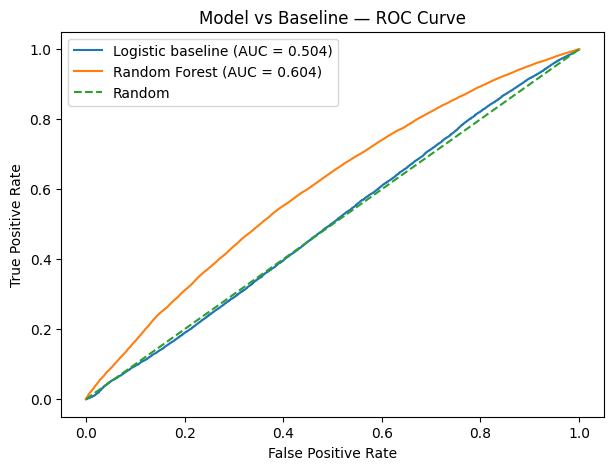

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_prob)
model_fpr, model_tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(7, 5))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Logistic baseline (AUC = {roc_auc_score(y_test, baseline_prob):.3f})"
)

plt.plot(
    model_fpr,
    model_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model vs Baseline — ROC Curve")
plt.legend()

plt.savefig(
    "paper_artifacts/roc_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Top 50:
  Logistic baseline Precision@50: 0.460
  Random Forest Precision@50: 0.880

Top 100:
  Logistic baseline Precision@100: 0.550
  Random Forest Precision@100: 0.870

Top 500:
  Logistic baseline Precision@500: 0.546
  Random Forest Precision@500: 0.840



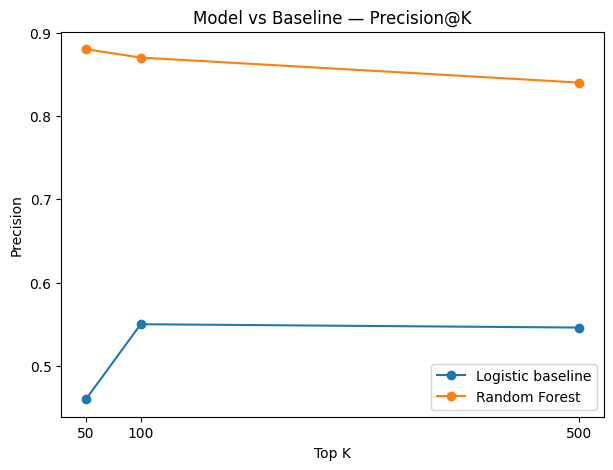

In [ ]:
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt

ks = [50, 100, 500]
baseline_precisions = []
model_precisions = []

for k in ks:
    baseline_top_k = y_test.iloc[baseline_prob.argsort()[::-1][:k]]
    model_top_k = y_test.iloc[prob.argsort()[::-1][:k]]

    baseline_precision = precision_score(
        baseline_top_k,
        [1] * k
    )

    model_precision = precision_score(
        model_top_k,
        [1] * k
    )

    baseline_precisions.append(baseline_precision)
    model_precisions.append(model_precision)

    print(f"Top {k}:")
    print(f"  Logistic baseline Precision@{k}: {baseline_precision:.3f}")
    print(f"  Random Forest Precision@{k}: {model_precision:.3f}")
    print()

plt.figure(figsize=(7, 5))

plt.plot(
    ks,
    baseline_precisions,
    marker="o",
    label="Logistic baseline"
)

plt.plot(
    ks,
    model_precisions,
    marker="o",
    label="Random Forest"
)

plt.xlabel("Top K")
plt.ylabel("Precision")
plt.title("Model vs Baseline — Precision@K")
plt.xticks(ks)
plt.legend()

plt.savefig(
    "paper_artifacts/precision_at_k.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

os.makedirs("paper_artifacts", exist_ok=True)
print("Folder ready:", os.path.abspath("paper_artifacts"))

Folder ready: /content/paper_artifacts


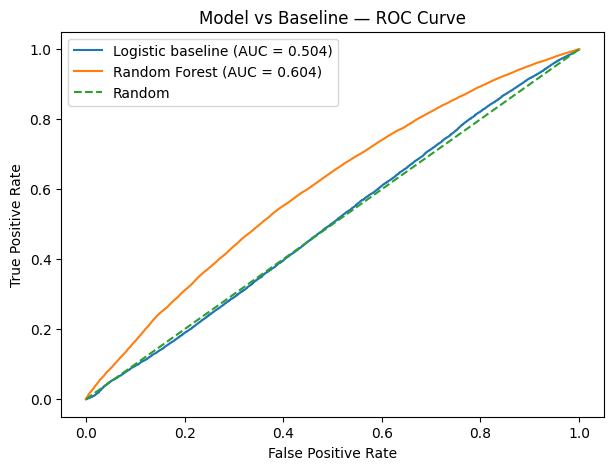

Saved correctly: paper_artifacts/roc_curve.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_prob)
model_fpr, model_tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(7, 5))

plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Logistic baseline (AUC = {roc_auc_score(y_test, baseline_prob):.3f})"
)

plt.plot(
    model_fpr,
    model_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, prob):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model vs Baseline — ROC Curve")
plt.legend()

plt.savefig("paper_artifacts/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

print("Saved correctly: paper_artifacts/roc_curve.png")

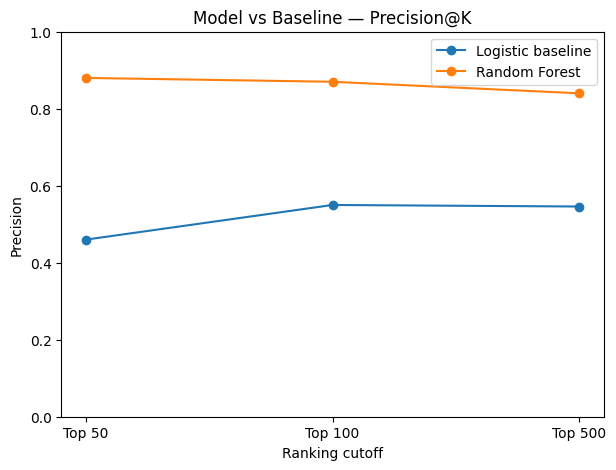

Saved correctly: paper_artifacts/precision_at_k.png


In [ ]:
import matplotlib.pyplot as plt

k_values = [50, 100, 500]
baseline_precision = [0.460, 0.550, 0.546]
model_precision = [0.880, 0.870, 0.840]

x = range(len(k_values))

plt.figure(figsize=(7, 5))

plt.plot(x, baseline_precision, marker="o", label="Logistic baseline")
plt.plot(x, model_precision, marker="o", label="Random Forest")

plt.xticks(x, [f"Top {k}" for k in k_values])
plt.xlabel("Ranking cutoff")
plt.ylabel("Precision")
plt.title("Model vs Baseline — Precision@K")
plt.ylim(0, 1)
plt.legend()


plt.savefig("paper_artifacts/precision_at_k.png", dpi=300, bbox_inches="tight")

plt.show()

print("Saved correctly: paper_artifacts/precision_at_k.png")

## 5. A first honest model

Same shape as notebook 02: define a label, hold out data, compare against a dumb baseline.
Label: *did impressions decline by more than 20% month-over-month?* — built only from columns
that exist **before** the window we predict. (Momentum features from the last 30 days predicting
a label defined on those same 30 days would be leakage — so here the features come from the
prev-30 window and query-mix, and the label from the last-30 outcome.)


Whatever number you just got: interrogate it before you believe it. Which feature carries the
signal? Does it survive a per-client split (train on some clients, test on others)? That
question — *does it generalize across clients?* — is exactly what separates a capstone-grade
result from a lucky split.

## Your turn

1. Re-run section 3 with a **90-day** window and a `HAVING` threshold of your choice.
2. Add one feature you believe in (position volatility? weekend share? query concentration?).
3. Replace the random split with **GroupShuffleSplit on `client_hash_id`** and compare.

## Working locally instead

```python
from huggingface_hub import snapshot_download
path = snapshot_download(repo_id='FlyRank/internship-warehouse', repo_type='dataset',
                         allow_patterns=['dim_*.parquet', 'fact_content_query_90d.parquet',
                                         'fact_content_daily_performance/month=2026-0*/*.parquet'])
```
Then point `REL` at that local path. Download only the month partitions you need — the
`allow_patterns` filter above is the whole trick.

---

**Where this fits:** every lane brief assumes you can produce per-content feature tables like
the one you just built. The lane datasets under the `lanes` HF repo are pre-cut examples of
exactly this pattern — but for the capstone, features you engineered yourself from the full
release beat any pre-cut file.
